In [1]:
import xarray as xr
import pandas as pd
import cartopy as ctpy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patheffects as pe
import matplotlib.lines as mlines
import seaborn as sns
import importlib
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import metpy.calc as mpcalc
import scipy.stats as stat
import nctoolkit as nc
import xcdat
import pickle
import dask.array as da

from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from numpy import *
from netCDF4 import Dataset
from datetime import datetime, timedelta
from metpy.units import units
from metpy.calc import heat_index
from metpy.units import units
import json
import math
import sys

import filepaths as filepaths
import model_preprocess as model_prep
import calculations as dr_g_calcs
import dictionary as dicts
importlib.reload(filepaths)
importlib.reload(model_prep)
importlib.reload(dr_g_calcs)
importlib.reload(dicts)


nctoolkit is using Climate Data Operators version 2.0.5


<module 'dictionary' from '/home/rgaal/notebooks/newer_stuff/dictionary.py'>

In [2]:
yr_i=1981
yr_f=2005
var_choice='pr'
label_choice='pr_mm'
wrf_var='RAINNC'
plot_var='Precipitation'

timeframe='historical'

location_strs=['South Florida']
location_abbrevs=['South FL']
so_fl_ll=[25.,-82.]
so_fl_ur=[27.,-80.]
locations=[so_fl_ll,so_fl_ur]
lat_arr=array(locations)[:,0]
lon_arr=array(locations)[:,1]

In [3]:
files=filepaths.era5_filepath(var_choice)
era5=model_prep.era5_open_file(files,var_choice,str(yr_i),str(yr_f))
era5=era5.sel(lat=slice(lat_arr[0],lat_arr[1]),lon=slice(lon_arr[0],lon_arr[1]))
counts=ravel((era5.groupby('time.month')[1][label_choice].values)).shape[0]

d,samples1=dicts.initial_dict_scatter(era5,var_choice,label_choice,timeframe,str(yr_i),str(yr_f))

Engine 'cfgrib' loading failed:
libffi.so.7: cannot open shared object file: No such file or directory


inserted data for group/month:  1
inserted data for group/month:  2
inserted data for group/month:  3
inserted data for group/month:  4
inserted data for group/month:  5
inserted data for group/month:  6
inserted data for group/month:  7
inserted data for group/month:  8
inserted data for group/month:  9
inserted data for group/month:  10
inserted data for group/month:  11
inserted data for group/month:  12


In [4]:
%%time
#future is only cmcc,fgoals,and hiram
coupled_list1=[]
if (timeframe=='historical'):
    dicts.coupled_highresmip_dict_scatter(coupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='fgoals')
    dicts.coupled_highresmip_dict_scatter(coupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cmcc')
    dicts.coupled_highresmip_dict_scatter(coupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='ecmwf')
    dicts.coupled_highresmip_dict_scatter(coupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hiram')
else:
    dicts.coupled_highresmip_dict_scatter(coupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='fgoals')
    dicts.coupled_highresmip_dict_scatter(coupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cmcc')
    dicts.coupled_highresmip_dict_scatter(coupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hiram')

Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode tim

created column:  fgoals
inserted data for group/month:  1
inserted data for group/month:  2
inserted data for group/month:  3
inserted data for group/month:  4
inserted data for group/month:  5
inserted data for group/month:  6
inserted data for group/month:  7
inserted data for group/month:  8
inserted data for group/month:  9
inserted data for group/month:  10
inserted data for group/month:  11
inserted data for group/month:  12
done with dictionary key:  fgoals
created column:  cmcc
inserted data for group/month:  1
inserted data for group/month:  2
inserted data for group/month:  3
inserted data for group/month:  4
inserted data for group/month:  5
inserted data for group/month:  6
inserted data for group/month:  7
inserted data for group/month:  8
inserted data for group/month:  9
inserted data for group/month:  10
inserted data for group/month:  11
inserted data for group/month:  12
done with dictionary key:  cmcc
created column:  ecmwf
inserted data for group/month:  1
inserted 

In [5]:
%%time
#future is only cam,fgoals,mri,cmcc,and hiram
uncoupled_list1=[]
if (timeframe=='historical'):
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cmcc')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cam-mpas')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='ecmwf')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hiram')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='mri')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='fgoals')
else:
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='fgoals')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cmcc')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cam-mpas')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hiram')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='mri')

created column:  cmcc
inserted data for group/month:  1
inserted data for group/month:  2
inserted data for group/month:  3
inserted data for group/month:  4
inserted data for group/month:  5
inserted data for group/month:  6
inserted data for group/month:  7
inserted data for group/month:  8
inserted data for group/month:  9
inserted data for group/month:  10
inserted data for group/month:  11
inserted data for group/month:  12
done with dictionary key:  cmcc
created column:  cam-mpas
inserted data for group/month:  1
inserted data for group/month:  2
inserted data for group/month:  3
inserted data for group/month:  4
inserted data for group/month:  5
inserted data for group/month:  6
inserted data for group/month:  7
inserted data for group/month:  8
inserted data for group/month:  9
inserted data for group/month:  10
inserted data for group/month:  11
inserted data for group/month:  12
done with dictionary key:  cam-mpas
created column:  ecmwf
inserted data for group/month:  1
inser

Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode tim

created column:  fgoals
inserted data for group/month:  1
inserted data for group/month:  2
inserted data for group/month:  3
inserted data for group/month:  4
inserted data for group/month:  5
inserted data for group/month:  6
inserted data for group/month:  7
inserted data for group/month:  8
inserted data for group/month:  9
inserted data for group/month:  10
inserted data for group/month:  11
inserted data for group/month:  12
done with dictionary key:  fgoals
CPU times: user 6.64 s, sys: 450 ms, total: 7.09 s
Wall time: 9.51 s


In [6]:
%%time
dicts.mesaclip_dict_scatter(coupled_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f))

created key in ensemble 0 1
retrieving ensemble member:,01
created column:  1
(1600,)
inserted data for group/month:  1
(1600,)
inserted data for group/month:  2
(1600,)
inserted data for group/month:  3
(1600,)
inserted data for group/month:  4
(1600,)
inserted data for group/month:  5
(1600,)
inserted data for group/month:  6
(1600,)
inserted data for group/month:  7
(1600,)
inserted data for group/month:  8
(1600,)
inserted data for group/month:  9
(1600,)
inserted data for group/month:  10
(1600,)
inserted data for group/month:  11
(1600,)
inserted data for group/month:  12
done with dictionary key:  1
created key in ensemble 0 2
retrieving ensemble member:,02
created column:  2
(1600,)
inserted data for group/month:  1
(1600,)
inserted data for group/month:  2
(1600,)
inserted data for group/month:  3
(1600,)
inserted data for group/month:  4
(1600,)
inserted data for group/month:  5
(1600,)
inserted data for group/month:  6
(1600,)
inserted data for group/month:  7
(1600,)
insert

In [7]:
%%time
downscale_list1=[]

dicts.gddp_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cesm2')
dicts.gddp_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cnrm')
dicts.gddp_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hadgem3-mm')
dicts.gddp_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hadgem3-ll')
dicts.gddp_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='ipsl')
dicts.gddp_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='miroc6')
dicts.gddp_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='mpi')

dicts.bccaq_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cesm2')
dicts.bccaq_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cnrm')
dicts.bccaq_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hadgem3-mm')
dicts.bccaq_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hadgem3-ll')
dicts.bccaq_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='ipsl')
dicts.bccaq_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='miroc6')
dicts.bccaq_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='mpi')

dicts.loca_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cesm2')
dicts.loca_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cnrm')
dicts.loca_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hadgem3-mm')
dicts.loca_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hadgem3-ll')
dicts.loca_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='ipsl')
dicts.loca_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='miroc6')
dicts.loca_dict_scatter(downscale_list1,d,samples1,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='mpi')

created column:  cesm2
inserted data for group/month:  1
inserted data for group/month:  2
inserted data for group/month:  3
inserted data for group/month:  4
inserted data for group/month:  5
inserted data for group/month:  6
inserted data for group/month:  7
inserted data for group/month:  8
inserted data for group/month:  9
inserted data for group/month:  10
inserted data for group/month:  11
inserted data for group/month:  12
done with dictionary key:  cesm2
created column:  cnrm
inserted data for group/month:  1
inserted data for group/month:  2
inserted data for group/month:  3
inserted data for group/month:  4
inserted data for group/month:  5
inserted data for group/month:  6
inserted data for group/month:  7
inserted data for group/month:  8
inserted data for group/month:  9
inserted data for group/month:  10
inserted data for group/month:  11
inserted data for group/month:  12
done with dictionary key:  cnrm
created column:  hadgem3-mm
inserted data for group/month:  1
insert

In [8]:
d_agg_plot_coupled1=dicts.agg_dicts_scatter(d,coupled_list1)
d_agg_plot_uncoupled1=dicts.agg_dicts_scatter(d,uncoupled_list1)
d_agg_plot_downscale1=dicts.agg_dicts_scatter(d,downscale_list1)

FGOALS-f3-H - Coupled
CMCC-CM2-VHR4 - Coupled
ECMWF-IFS-HR - Coupled
HiRAM-SIT-HR - Coupled
mesaclip 1
mesaclip 2
mesaclip 3
mesaclip 4
mesaclip 5
mesaclip 6
mesaclip 7
mesaclip 8
mesaclip 9
mesaclip 10
CMCC-CM2-VHR4 - Uncoupled
CAM-MPAS-HR - Uncoupled
ECMWF-IFS-HR - Uncoupled
HiRAM-SIT-HR - Uncoupled
MRI-AGCM3-2-S - Uncoupled
FGOALS-f3-H - Uncoupled
CESM2-LENS - BCSD
CNRM-CM6-1 - BCSD
HadGEM3-GC31-MM - BCSD
HadGEM3-GC31-LL - BCSD
IPSL-CM6A-LR - BCSD
MIROC6 - BCSD
MPI-ESM1-2-HR - BCSD
CESM2-LENS - BCCAQ
HadGEM3-GC31-LL - BCCAQ
IPSL-CM6A-LR - BCCAQ
MIROC6 - BCCAQ
CNRM-CM6-1 - LOCA
HadGEM3-GC31-MM - LOCA
HadGEM3-GC31-LL - LOCA
IPSL-CM6A-LR - LOCA
MIROC6 - LOCA
MPI-ESM1-2-HR - LOCA


In [9]:
d_agg_plot_coupled1['obs_mask']=d_agg_plot_coupled1['obs_data'][d_agg_plot_coupled1['obs_data']>=1.]
d_agg_plot_coupled1['model_mask']=d_agg_plot_coupled1['model_data'][d_agg_plot_coupled1['model_data']>=1.]

d_agg_plot_uncoupled1['obs_mask']=d_agg_plot_uncoupled1['obs_data'][d_agg_plot_uncoupled1['obs_data']>=1.]
d_agg_plot_uncoupled1['model_mask']=d_agg_plot_uncoupled1['model_data'][d_agg_plot_uncoupled1['model_data']>=1.]

d_agg_plot_downscale1['obs_mask']=d_agg_plot_downscale1['obs_data'][d_agg_plot_downscale1['obs_data']>=1.]
d_agg_plot_downscale1['model_mask']=d_agg_plot_downscale1['model_data'][d_agg_plot_downscale1['model_data']>=1.]

In [10]:
yr_i=2015
yr_f=2024
var_choice='pr'
label_choice='pr_mm'
wrf_var='RAINNC'
plot_var='Precipitation'

timeframe='future'

location_strs=['South Florida']
location_abbrevs=['South FL']
so_fl_ll=[25.,-82.]
so_fl_ur=[27.,-80.]
locations=[so_fl_ll,so_fl_ur]
lat_arr=array(locations)[:,0]
lon_arr=array(locations)[:,1]

In [11]:
files=filepaths.era5_filepath(var_choice)
era5=model_prep.era5_open_file(files,var_choice,str(yr_i),str(yr_f))
era5=era5.sel(lat=slice(lat_arr[0],lat_arr[1]),lon=slice(lon_arr[0],lon_arr[1]))
counts=ravel((era5.groupby('time.month')[1][label_choice].values)).shape[0]

e,samples2=dicts.initial_dict_scatter(era5,var_choice,label_choice,timeframe,str(yr_i),str(yr_f))

inserted data for group/month:  1
inserted data for group/month:  2
inserted data for group/month:  3
inserted data for group/month:  4
inserted data for group/month:  5
inserted data for group/month:  6
inserted data for group/month:  7
inserted data for group/month:  8
inserted data for group/month:  9
inserted data for group/month:  10
inserted data for group/month:  11
inserted data for group/month:  12


In [12]:
%%time
#future is only cmcc,fgoals,and hiram
coupled_list2=[]
if (timeframe=='historical'):
    dicts.coupled_highresmip_dict_scatter(coupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='fgoals')
    dicts.coupled_highresmip_dict_scatter(coupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cmcc')
    dicts.coupled_highresmip_dict_scatter(coupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='ecmwf')
    dicts.coupled_highresmip_dict_scatter(coupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hiram')
else:
    dicts.coupled_highresmip_dict_scatter(coupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='fgoals')
    dicts.coupled_highresmip_dict_scatter(coupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cmcc')
    dicts.coupled_highresmip_dict_scatter(coupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hiram')

Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode tim

created column:  fgoals
inserted data for group/month:  1
inserted data for group/month:  2
inserted data for group/month:  3
inserted data for group/month:  4
inserted data for group/month:  5
inserted data for group/month:  6
inserted data for group/month:  7
inserted data for group/month:  8
inserted data for group/month:  9
inserted data for group/month:  10
inserted data for group/month:  11
inserted data for group/month:  12
done with dictionary key:  fgoals
created column:  cmcc
inserted data for group/month:  1
inserted data for group/month:  2
inserted data for group/month:  3
inserted data for group/month:  4
inserted data for group/month:  5
inserted data for group/month:  6
inserted data for group/month:  7
inserted data for group/month:  8
inserted data for group/month:  9
inserted data for group/month:  10
inserted data for group/month:  11
inserted data for group/month:  12
done with dictionary key:  cmcc
created column:  hiram
inserted data for group/month:  1
inserted 

uncoupled models dictionary - annual climatology (grid)

In [13]:
%%time
#future is only cam,fgoals,mri,cmcc,and hiram
uncoupled_list2=[]
if (timeframe=='historical'):
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cmcc')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cam-mpas')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='ecmwf')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hiram')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='mri')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='fgoals')
else:
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='fgoals')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cmcc')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cam-mpas')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hiram')
    dicts.uncoupled_highresmip_dict_scatter(uncoupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='mri')

Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode tim

created column:  fgoals
inserted data for group/month:  1
inserted data for group/month:  2
inserted data for group/month:  3
inserted data for group/month:  4
inserted data for group/month:  5
inserted data for group/month:  6
inserted data for group/month:  7
inserted data for group/month:  8
inserted data for group/month:  9
inserted data for group/month:  10
inserted data for group/month:  11
inserted data for group/month:  12
done with dictionary key:  fgoals
created column:  cmcc
inserted data for group/month:  1
inserted data for group/month:  2
inserted data for group/month:  3
inserted data for group/month:  4
inserted data for group/month:  5
inserted data for group/month:  6
inserted data for group/month:  7
inserted data for group/month:  8
inserted data for group/month:  9
inserted data for group/month:  10
inserted data for group/month:  11
inserted data for group/month:  12
done with dictionary key:  cmcc
created column:  cam-mpas
inserted data for group/month:  1
insert

In [14]:
%%time
# importlib.reload(dicts)
# print(samples)
dicts.mesaclip_dict_scatter(coupled_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f))

created key in ensemble 0 1
retrieving ensemble member:,01
created column:  1
(640,)
inserted data for group/month:  1
(640,)
inserted data for group/month:  2
(640,)
inserted data for group/month:  3
(640,)
inserted data for group/month:  4
(640,)
inserted data for group/month:  5
(640,)
inserted data for group/month:  6
(640,)
inserted data for group/month:  7
(640,)
inserted data for group/month:  8
(640,)
inserted data for group/month:  9
(640,)
inserted data for group/month:  10
(640,)
inserted data for group/month:  11
(640,)
inserted data for group/month:  12
done with dictionary key:  1
created key in ensemble 0 2
retrieving ensemble member:,02
created column:  2
(640,)
inserted data for group/month:  1
(640,)
inserted data for group/month:  2
(640,)
inserted data for group/month:  3
(640,)
inserted data for group/month:  4
(640,)
inserted data for group/month:  5
(640,)
inserted data for group/month:  6
(640,)
inserted data for group/month:  7
(640,)
inserted data for group/mo

In [15]:
%%time
downscale_list2=[]

dicts.gddp_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cesm2')
dicts.gddp_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cnrm')
dicts.gddp_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hadgem3-mm')
dicts.gddp_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hadgem3-ll')
dicts.gddp_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='ipsl')
dicts.gddp_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='miroc6')
dicts.gddp_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='mpi')

dicts.bccaq_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cesm2')
dicts.bccaq_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cnrm')
dicts.bccaq_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hadgem3-mm')
dicts.bccaq_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hadgem3-ll')
dicts.bccaq_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='ipsl')
dicts.bccaq_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='miroc6')
dicts.bccaq_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='mpi')

# dicts.loca_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cesm2')
dicts.loca_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='cnrm')
dicts.loca_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hadgem3-mm')
dicts.loca_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='hadgem3-ll')
dicts.loca_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='ipsl')
dicts.loca_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='miroc6')
dicts.loca_dict_scatter(downscale_list2,e,samples2,var_choice,label_choice,timeframe,str(yr_i),str(yr_f),model_name='mpi')

created column:  cesm2
inserted data for group/month:  1
inserted data for group/month:  2
inserted data for group/month:  3
inserted data for group/month:  4
inserted data for group/month:  5
inserted data for group/month:  6
inserted data for group/month:  7
inserted data for group/month:  8
inserted data for group/month:  9
inserted data for group/month:  10
inserted data for group/month:  11
inserted data for group/month:  12
done with dictionary key:  cesm2
created column:  cnrm
inserted data for group/month:  1
inserted data for group/month:  2
inserted data for group/month:  3
inserted data for group/month:  4
inserted data for group/month:  5
inserted data for group/month:  6
inserted data for group/month:  7
inserted data for group/month:  8
inserted data for group/month:  9
inserted data for group/month:  10
inserted data for group/month:  11
inserted data for group/month:  12
done with dictionary key:  cnrm
created column:  hadgem3-mm
inserted data for group/month:  1
insert

In [16]:
d_agg_plot_coupled2=dicts.agg_dicts_scatter(e,coupled_list2)
d_agg_plot_uncoupled2=dicts.agg_dicts_scatter(e,uncoupled_list2)
d_agg_plot_downscale2=dicts.agg_dicts_scatter(e,downscale_list2)

FGOALS-f3-H - Coupled
CMCC-CM2-VHR4 - Coupled
HiRAM-SIT-HR - Coupled
mesaclip 1
mesaclip 2
mesaclip 3
mesaclip 4
mesaclip 5
mesaclip 6
mesaclip 7
mesaclip 8
mesaclip 10
FGOALS-f3-H - Uncoupled
CMCC-CM2-VHR4 - Uncoupled
CAM-MPAS-HR - Uncoupled
HiRAM-SIT-HR - Uncoupled
MRI-AGCM3-2-S - Uncoupled
CESM2-LENS - BCSD
CNRM-CM6-1 - BCSD
HadGEM3-GC31-MM - BCSD
HadGEM3-GC31-LL - BCSD
IPSL-CM6A-LR - BCSD
MIROC6 - BCSD
MPI-ESM1-2-HR - BCSD
CESM2-LENS - BCCAQ
HadGEM3-GC31-LL - BCCAQ
IPSL-CM6A-LR - BCCAQ
MIROC6 - BCCAQ
CNRM-CM6-1 - LOCA
HadGEM3-GC31-MM - LOCA
HadGEM3-GC31-LL - LOCA
IPSL-CM6A-LR - LOCA
MIROC6 - LOCA
MPI-ESM1-2-HR - LOCA


In [17]:
d_agg_plot_coupled2['obs_mask']=d_agg_plot_coupled2['obs_data'][d_agg_plot_coupled2['obs_data']>=1.]
d_agg_plot_coupled2['model_mask']=d_agg_plot_coupled2['model_data'][d_agg_plot_coupled2['model_data']>=1.]

d_agg_plot_uncoupled2['obs_mask']=d_agg_plot_uncoupled2['obs_data'][d_agg_plot_uncoupled2['obs_data']>=1.]
d_agg_plot_uncoupled2['model_mask']=d_agg_plot_uncoupled2['model_data'][d_agg_plot_uncoupled2['model_data']>=1.]

d_agg_plot_downscale2['obs_mask']=d_agg_plot_downscale2['obs_data'][d_agg_plot_downscale2['obs_data']>=1.]
d_agg_plot_downscale2['model_mask']=d_agg_plot_downscale2['model_data'][d_agg_plot_downscale2['model_data']>=1.]

In [19]:
def add_label_band_x(ax, top, bottom, label, *, spine_pos=-0.05, tip_pos=-0.02):
    """
    Helper function to add bracket around y-tick labels.

    Parameters
    ----------
    ax : matplotlib.Axes
        The axes to add the bracket to

    top, bottom : floats
        The positions in *data* space to bracket on the y-axis

    label : str
        The label to add to the bracket

    spine_pos, tip_pos : float, optional
        The position in *axes fraction* of the spine and tips of the bracket.
        These will typically be negative

    Returns
    -------
    bracket : matplotlib.patches.PathPatch
        The "bracket" Aritst.  Modify this Artist to change the color etc of
        the bracket from the defaults.

    txt : matplotlib.text.Text
        The label Artist.  Modify this to change the color etc of the label
        from the defaults.

    """
    # grab the yaxis blended transform
    transform = ax.get_xaxis_transform()

    # add the bracket
    bracket = mpatches.PathPatch(
        mpath.Path(
            [
                [top, tip_pos],
                [top, spine_pos],
                [bottom, spine_pos],
                [bottom, tip_pos],
            ]
        ),
        transform=transform,
        clip_on=False,
        facecolor="none",
        edgecolor="k",
        linewidth=2,
    )
    ax.add_artist(bracket)

    # add the label
    txt = ax.text(
        (top+bottom)/2,
        spine_pos+0.3,
        label,
        ha="center",
        va="bottom",
        rotation="horizontal",
        clip_on=False,
        transform=transform,fontsize=11,fontweight='bold'
    )

    return bracket, txt

In [20]:
def add_label_band_y(ax, top, bottom, label, *, spine_pos=-0.05, tip_pos=-0.02,color=None):
    """
    Helper function to add bracket around y-tick labels.

    Parameters
    ----------
    ax : matplotlib.Axes
        The axes to add the bracket to

    top, bottom : floats
        The positions in *data* space to bracket on the y-axis

    label : str
        The label to add to the bracket

    spine_pos, tip_pos : float, optional
        The position in *axes fraction* of the spine and tips of the bracket.
        These will typically be negative

    Returns
    -------
    bracket : matplotlib.patches.PathPatch
        The "bracket" Aritst.  Modify this Artist to change the color etc of
        the bracket from the defaults.

    txt : matplotlib.text.Text
        The label Artist.  Modify this to change the color etc of the label
        from the defaults.

    """
    # grab the yaxis blended transform
    transform = ax.get_yaxis_transform()

    # add the bracket
    bracket = mpatches.PathPatch(
        mpath.Path(
            [
                [tip_pos, top],
                [spine_pos, top],
                [spine_pos, bottom],
                [tip_pos, bottom],
            ]
        ),
        transform=transform,
        clip_on=False,
        facecolor="none",
        edgecolor="k",
        linewidth=2,
    )
    ax.add_artist(bracket)

    # add the label
    txt = ax.text(
        spine_pos-0.04,
        (top + bottom) / 2,
        label,ha="right",
        va="center",
        rotation="vertical",
        clip_on=False,color='k',
        transform=transform,fontsize=11,fontweight='bold',
        #bbox=dict(facecolor=color,alpha=0.5,boxstyle='round')#pad=1
    )

    return bracket, txt

In [21]:
def scatter_hist(dplot,ax, ax_histx=None, ax_histy=None,k=None,i=None,shift=None,color=None,color_line=None):
    # no labels
    
    from matplotlib.colors import LinearSegmentedColormap
    # Fetch the original colormap
    original_cmap = plt.get_cmap(color)
    
    # Define your start and end portions (values between 0.0 and 1.0)
    start_frac = 0.2
    end_frac = 0.8
    
    # Extract the colors in that specific range
    colors = original_cmap(linspace(start_frac, end_frac, 256))
    
    # Create a new, restricted colormap
    cropped_cmap = LinearSegmentedColormap.from_list('cropped_'+cmap_val[i], colors)

     # the scatter plot:
    g=sns.kdeplot(data=dplot, x="model_mask", y='obs_mask',ax=ax,fill=True,levels=[0.05,0.2, 0.4, 0.6, 0.8,1.],zorder=2,alpha=0.75,cmap=cropped_cmap)
        
    g.plot([0, 1], [0, 1], transform=g.transAxes, ls='-', color='dimgrey',linewidth=0.9,zorder=1)
    g.grid(True,zorder=0,color='lightgrey')
   
    g.set_xlim(-1.5,16)
    g.set_ylim(-1.5,16)
    g.set_xlabel('Model Data (mm/day)')
    g.set_xticks(arange(0,19,2))
   
    if (shift==4):
        g.set_xlabel('Model Data (mm/day)')
        g.set_xticks(arange(0,19,2))
    else:
        g.set_xlabel('')
        g.set_xticks(arange(0,19,2),labels='')
        
    if (k==0):
        g.set_ylabel('Verification Data (mm/day)')
        g.set_yticks(arange(0,19,2))
    else:
        g.set_ylabel('')
        g.set_yticks(arange(0,19,2),labels='')
        
    g.set_xlim(-1.5,16)
    g.set_ylim(-1.5,16)
    if (k==0):
        add_label_band_y(g, 16.5,-2., label=plot_labels[i],spine_pos=-0.3, tip_pos=-0.25,color=color_line)
    

shift_init= 0
i= 0
k= 0
k= 1
shift= 2
i= 1
k= 0
k= 1
shift= 4
i= 2
k= 0
k= 1
shift= 6
CPU times: user 5min 17s, sys: 48.4 s, total: 6min 5s
Wall time: 4min 44s


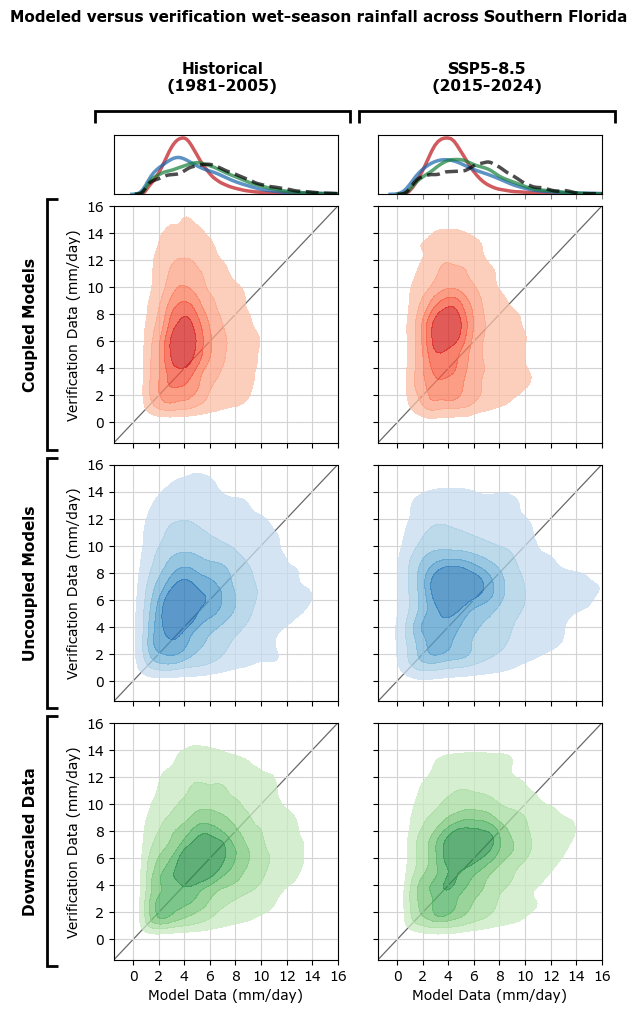

In [22]:
%%time
import matplotlib.path as mpath
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "Verdana" 
plt.rcParams['savefig.dpi'] = 300
color=sns.color_palette('tab20c')
color_val=[]

from matplotlib.colors import LinearSegmentedColormap

cmap_val=['Reds','Blues','Greens']
for i in range(3):
   # Fetch the original colormap
    cmap = plt.get_cmap(cmap_val[i])
    darkest_rgba = cmap(0.8)
    color_val.append(darkest_rgba)


fig, ax = plt.subplots(nrows=3,ncols=2,figsize=(6,9.5),constrained_layout=True) #width,height
axs_flat=ax.flat

time_label=['Historical\n(1981-2005)','SSP5-8.5\n(2015-2024)']

dplots=[d_agg_plot_coupled1,d_agg_plot_uncoupled1,d_agg_plot_downscale1]
eplots=[d_agg_plot_coupled2,d_agg_plot_uncoupled2,d_agg_plot_downscale2]
plot_labels=['Coupled Models','Uncoupled Models','Downscaled Data']
shift=0

print('shift_init=',shift)
for i,j in enumerate(dplots):
    print('i=',i)
    for k,l in enumerate(time_label):
        print('k=',k)
        # print('axs - ',k+shift)
        if (k==0):
            myplot=dplots[i].where(dplots[i]['season']=='Wet Season')
        else:
            myplot=eplots[i].where(eplots[i]['season']=='Wet Season')
        
        scatter_hist(myplot,axs_flat[shift+k],k=k,i=i,shift=shift,color=cmap_val[i],color_line=color_val[i])

    
    shift+=2
    print('shift=',shift)


ax_hist0 = axs_flat[0].inset_axes([0, 1.05, 1, 0.25], sharex=axs_flat[0])
xx=sns.kdeplot(data=dplots[0].where(dplots[0]['season']=='Wet Season'), x="model_mask", ax=ax_hist0,label=plot_labels[0],color=color_val[0],alpha=0.7,linewidth=2.5)
sns.kdeplot(data=dplots[1].where(dplots[1]['season']=='Wet Season'), x="model_mask", ax=ax_hist0,label=plot_labels[1],color=color_val[1],alpha=0.7,linewidth=2.5)
sns.kdeplot(data=dplots[2].where(dplots[2]['season']=='Wet Season'), x="model_mask", ax=ax_hist0,label=plot_labels[2],color=color_val[2],alpha=0.7,linewidth=2.5)
sns.kdeplot(data=dplots[2].where(dplots[2]['season']=='Wet Season'), x="obs_mask", ax=ax_hist0,label='Verification Data',color='k',alpha=0.7,linewidth=2.5,linestyle='--')
xx.set_ylabel('')
xx.set_xlabel('')
xx.tick_params(colors='white', which='both',left=False,right=False,top=False,bottom=False,labeltop=False,labelleft=False,labelright=False,labelbottom=False)

add_label_band_x(xx,17,-3, label=time_label[0],spine_pos=1.4, tip_pos=1.2)

ax_hist1 = axs_flat[1].inset_axes([0, 1.05, 1, 0.25], sharex=axs_flat[1])
yy=sns.kdeplot(data=eplots[0].where(eplots[0]['season']=='Wet Season'), x="model_mask", ax=ax_hist1,label=plot_labels[0],color=color_val[0],alpha=0.7,linewidth=2.5)
sns.kdeplot(data=eplots[1].where(eplots[1]['season']=='Wet Season'), x="model_mask", ax=ax_hist1,label=plot_labels[1],color=color_val[1],alpha=0.7,linewidth=2.5)
sns.kdeplot(data=eplots[2].where(eplots[2]['season']=='Wet Season'), x="model_mask", ax=ax_hist1,label=plot_labels[2],color=color_val[2],alpha=0.7,linewidth=2.5)
sns.kdeplot(data=eplots[2].where(eplots[2]['season']=='Wet Season'), x="obs_mask", ax=ax_hist1,label='Verification Data',color='k',alpha=0.7,linewidth=2.5,linestyle='--')
yy.set_ylabel('')
yy.set_xlabel('')
yy.tick_params(colors='grey', which='both',left=False,right=False,top=False,bottom=True,labeltop=False,labelleft=False,labelright=False,labelbottom=False)
    
add_label_band_x(yy,17,-3, label=time_label[1],spine_pos=1.4, tip_pos=1.2)

plt.suptitle('Modeled versus verification wet-season rainfall across Southern Florida',y=1.05,fontsize=11,fontweight='bold')
